In [41]:
import easyocr


reader = easyocr.Reader(['en', 'ro'])
rezultate = reader.readtext('test.png')

for (coordonate, text, probabilitate) in rezultate:
    print(f'Text: {text}, Probabilitate: {probabilitate:.2f}')
    print (f'Coordonate: {coordonate}')

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\aculm\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text: #cesta, Probabilitate: 0.97
Coordonate: [[np.int32(347), np.int32(29)], [np.int32(972), np.int32(29)], [np.int32(972), np.int32(281)], [np.int32(347), np.int32(281)]]
Text: @ste, Probabilitate: 0.57
Coordonate: [[np.int32(1079), np.int32(85)], [np.int32(1486), np.int32(85)], [np.int32(1486), np.int32(285)], [np.int32(1079), np.int32(285)]]
Text: Un, Probabilitate: 0.94
Coordonate: [[np.int32(1603), np.int32(142)], [np.int32(1765), np.int32(142)], [np.int32(1765), np.int32(267)], [np.int32(1603), np.int32(267)]]
Text: fest, Probabilitate: 0.37
Coordonate: [[np.int32(1851), np.int32(87)], [np.int32(2279), np.int32(87)], [np.int32(2279), np.int32(297)], [np.int32(1851), np.int32(297)]]
Text: B 5 _ vky!, Probabilitate: 0.30
Coordonate: [[np.int32(2424), np.int32(62)], [np.int32(3125), np.int32(62)], [np.int32(3125), 303], [np.int32(2424), 303]]


In [42]:
def calculeaza_levenshtein(text_corect, text_ocr):
    randuri = len(text_corect) + 1
    coloane = len(text_ocr) + 1
    matrice = [[0 for _ in range(coloane)] for _ in range(randuri)]

    for i in range(1, randuri):
        matrice[i][0] = i
    for j in range(1, coloane):
        matrice[0][j] = j

    for i in range(1, randuri):
        for j in range(1, coloane):
            if text_corect[i - 1] == text_ocr [j - 1]:
                cost_inlocuire = 0
            else:
                cost_inlocuire = 1

            matrice[i][j] = min(matrice[i - 1][j] + 1, matrice[i][j - 1] + 1, matrice[i - 1][j - 1] + cost_inlocuire) 

    return matrice[randuri - 1][coloane - 1]   

def calculeaza_cer(text_corect, text_ocr):
    distanta = calculeaza_levenshtein(text_corect, text_ocr)
    if len(text_corect) == 0:
        return 1.0
    return distanta / len(text_corect)

def calculeaza_wer(text_corect, text_ocr):
    cuvinte_corecte = text_corect.split()
    cuvinte_ocr = text_ocr.split()
    distanta = calculeaza_levenshtein(cuvinte_corecte, cuvinte_ocr)
    if len(cuvinte_corecte) == 0:
        return 1.0
    return distanta / len(cuvinte_corecte)

def calculeaza_hamming(text_corect, text_ocr):
    lungime_max = max(len(text_corect), len(text_ocr))
    text_corect_padded = text_corect.ljust(lungime_max)
    text_ocr_padded = text_ocr.ljust(lungime_max)
    distanta = 0
    for i in range(lungime_max):
        if text_corect_padded[i] != text_ocr_padded[i]:
            distanta += 1
    return distanta

def test():
    text_real = "motricitatea este greu de obtinut"
    text_ai = "nohgjictate aste gvlae be oltnintut"
    print("Eroare CER:", calculeaza_cer(text_real, text_ai))
    print("Eroare WER:", calculeaza_wer(text_real, text_ai))
    print("Eroare Hamming:", calculeaza_hamming(text_real, text_ai))
test()

Eroare CER: 0.45454545454545453
Eroare WER: 1.0
Eroare Hamming: 24


In [43]:
text_initial = "Acesta este un test. B5Dvky!"
print("Text initial:", text_initial)
text_ai = ""
for (coordonate, text, probabilitate) in rezultate:
    text_ai += text + " "
text_ai = text_ai.strip()
print("Text obtinut de ai:", text_ai)
print("Eroare CER:", calculeaza_cer(text_initial, text_ai))
print("Eroare WER:", calculeaza_wer(text_initial, text_ai))
print("Eroare Hamming:", calculeaza_hamming(text_initial, text_ai))

Text initial: Acesta este un test. B5Dvky!
Text obtinut de ai: #cesta @ste Un fest B 5 _ vky!
Eroare CER: 0.32142857142857145
Eroare WER: 1.6
Eroare Hamming: 14


In [44]:
def formateaza_cutie(coordonate_easyocr):
    xs = [point[0] for point in coordonate_easyocr]
    ys = [point[1] for point in coordonate_easyocr]
    return [min(xs), min(ys), max(xs), max(ys)]

def calculeaza_iou(cutie1, cutie2):
    xA = max(cutie1[0], cutie2[0])
    yA = max(cutie1[1], cutie2[1])
    xB = min(cutie1[2], cutie2[2])
    yB = min(cutie1[3], cutie2[3])

    latime_intersectie = max(0, xB - xA)
    inaltime_intersectie = max(0, yB - yA)
    aria_intersectie = latime_intersectie * inaltime_intersectie

    aria_cutie1 = (cutie1[2] - cutie1[0]) * (cutie1[3] - cutie1[1])
    aria_cutie2 = (cutie2[2] - cutie2[0]) * (cutie2[3] - cutie2[1])

    aria_reuniune = float(aria_cutie1 + aria_cutie2 - aria_intersectie)

    if aria_reuniune == 0:
        return 0.0
    
    return aria_intersectie / aria_reuniune

coordonate_brute_ai = rezultate[0][0]
cutie_ai = formateaza_cutie(coordonate_brute_ai)

cutie_reala = [cutie_ai[0] - 10, cutie_ai[1] - 10, cutie_ai[2] + 10, cutie_ai[3] + 10]

scor_iou = calculeaza_iou(cutie_ai, cutie_reala)
print("Scor IoU:", scor_iou)

Scor IoU: 0.8977428180574556


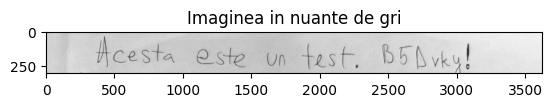

Text initial:  Acesta este un test. B5Dvky!
Text obtinut de ai dupa grayscalling: #cesta @ste Un fest B 5|vky !
Eroare CER dupa grayscalling: 0.2857142857142857
Eroare WER dupa grayscalling: 1.4
Eroare Hamming dupa grayscalling: 10


In [45]:
import cv2
import matplotlib.pyplot as plt

imagine = cv2.imread('test.png')
imagine_gray_scale = cv2.cvtColor(imagine, cv2.COLOR_BGR2GRAY)
plt.imshow(imagine_gray_scale, cmap='gray')
plt.title('Imaginea in nuante de gri')
plt.show()

rezultate_noi = reader.readtext(imagine_gray_scale)
text_ai_grayscale = ""
for (coordonate, text, probabilitate) in rezultate_noi:
    text_ai_grayscale += text + " "
text_ai_grayscale = text_ai_grayscale.strip()
print("Text initial: ", text_initial)
print("Text obtinut de ai dupa grayscalling:", text_ai_grayscale)
print("Eroare CER dupa grayscalling:", calculeaza_cer(text_initial, text_ai_grayscale))
print("Eroare WER dupa grayscalling:", calculeaza_wer(text_initial, text_ai_grayscale))
print("Eroare Hamming dupa grayscalling:", calculeaza_hamming(text_initial, text_ai_grayscale))

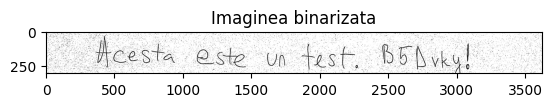

c:\Users\aculm\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text initial:  Acesta este un test. B5Dvky!
Text obtinut de ai dupa binarizare: #cesta @s+ Un +2s( 8 5 vky
Eroare CER dupa binarizare: 0.4642857142857143
Eroare WER dupa binarizare: 1.4
Eroare Hamming dupa binarizare: 20


In [46]:
imagine_blurata = cv2.GaussianBlur(imagine_gray_scale, (5, 5), 0)
imagine_binarizata = cv2.adaptiveThreshold(imagine_blurata, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
plt.imshow(imagine_binarizata, cmap='gray')
plt.title('Imaginea binarizata')
plt.show()

rezultate_binarizate = reader.readtext(imagine_binarizata)
text_ai_binarizat = ""
for (coordonate, text, probabilitate) in rezultate_binarizate:
    text_ai_binarizat += text + " "
text_ai_binarizat = text_ai_binarizat.strip()
print("Text initial: ", text_initial)
print("Text obtinut de ai dupa binarizare:", text_ai_binarizat)
print("Eroare CER dupa binarizare:", calculeaza_cer(text_initial, text_ai_binarizat))
print("Eroare WER dupa binarizare:", calculeaza_wer(text_initial, text_ai_binarizat))
print("Eroare Hamming dupa binarizare:", calculeaza_hamming(text_initial, text_ai_binarizat))

In [48]:
print("=== SUMARIZARE ===")
print("Eroare CER in functie de varianta de optimizare:")
print("Classic: ", calculeaza_cer(text_initial, text_ai))
print("Grayscale: ", calculeaza_cer(text_initial, text_ai_grayscale))
print("Binarizare: ", calculeaza_cer(text_initial, text_ai_binarizat))
print("-" * 30)
print("Eroare WER in functie de varianta de optimizare:")
print("Classic: ", calculeaza_wer(text_initial, text_ai))
print("Grayscale: ", calculeaza_wer(text_initial, text_ai_grayscale))
print("Binarizare: ", calculeaza_wer(text_initial, text_ai_binarizat))
print("-" * 30)
print("Eroare Hamming in functie de varianta de optimizare:")
print("Classic: ", calculeaza_hamming(text_initial, text_ai))
print("Grayscale: ", calculeaza_hamming(text_initial, text_ai_grayscale))
print("Binarizare: ", calculeaza_hamming(text_initial, text_ai_binarizat))

=== SUMARIZARE ===
Eroare CER in functie de varianta de optimizare:
Classic:  0.32142857142857145
Grayscale:  0.2857142857142857
Binarizare:  0.4642857142857143
------------------------------
Eroare WER in functie de varianta de optimizare:
Classic:  1.6
Grayscale:  1.4
Binarizare:  1.4
------------------------------
Eroare Hamming in functie de varianta de optimizare:
Classic:  14
Grayscale:  10
Binarizare:  20
